<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/cosmology_flrw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FLRW metric (Robertson-Walker-Metric)**

The Friedmann-Lemaître-Robertson-Walker (FLRW) metric describes a homogeneous, isotropic expanding universe. It's widely used in cosmology to describe the large-scale structure of spacetime. The FLRW metric is given by:

$
ds^2 = -c^2 dt^2 + a(t)^2 \left[ \frac{dr^2}{1 - k r^2} + r^2 (d\theta^2 + \sin^2\theta \, d\phi^2) \right]
$

Where:
- $ds^2 $: Spacetime interval (line element).
- $ c $: Speed of light.
- $t $: Cosmic time.
- $ a(t) $: Scale factor of the universe.
- $ r, \theta, \phi $: Spherical coordinates.
- $ k $: Curvature constant ($ k = 1 $ for closed, $ k = 0 $ for flat, and $ k = -1 $ for open universes).

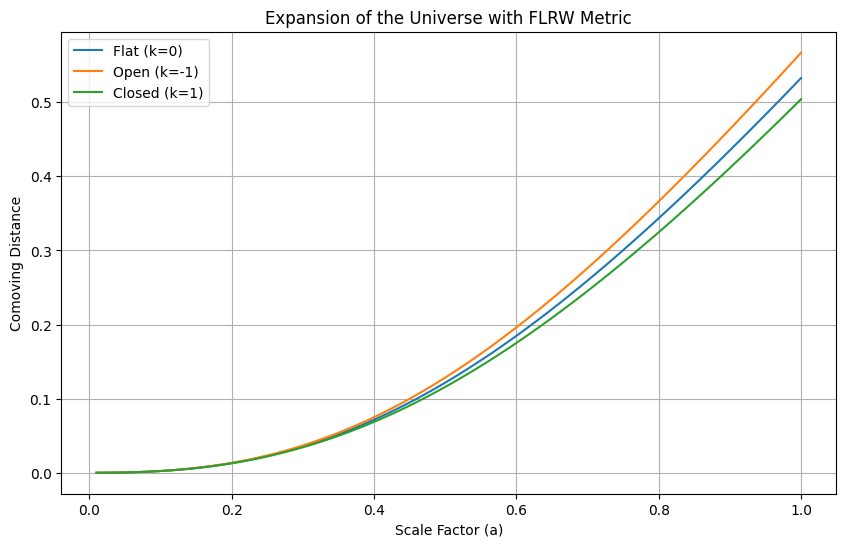

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Define the Friedmann-Lemaître-Robertson-Walker (FLRW) metric
def flrw_metric(a, Omega_m, Omega_k, Omega_lambda):
  """
  Calculates the Hubble parameter in the FLRW metric.

  Args:
    a: Scale factor.
    Omega_m: Matter density parameter.
    Omega_k: Curvature density parameter.
    Omega_lambda: Dark energy density parameter.

  Returns:
    The Hubble parameter.
  """
  return np.sqrt(Omega_m / a**3 + Omega_k / a**2 + Omega_lambda)

# Define the comoving distance
def comoving_distance(a, Omega_m, Omega_k, Omega_lambda):
  """
  Calculates the comoving distance.

  Args:
    a: Scale factor.
    Omega_m: Matter density parameter.
    Omega_k: Curvature density parameter.
    Omega_lambda: Dark energy density parameter.

  Returns:
    The comoving distance.
  """
  def integrand(a):
    return 1 / flrw_metric(a, Omega_m, Omega_k, Omega_lambda)
  return quad(integrand, 0, a)[0]

# Define the scale factors
a_values = np.linspace(0.01, 1, 100)

# Define the cosmological parameters
Omega_m = 0.3
Omega_lambda = 0.7

# Calculate the comoving distances for different curvatures
comoving_distances_flat = [comoving_distance(a, Omega_m, 0, Omega_lambda) for a in a_values]
comoving_distances_open = [comoving_distance(a, Omega_m, -0.1, Omega_lambda) for a in a_values]
comoving_distances_closed = [comoving_distance(a, Omega_m, 0.1, Omega_lambda) for a in a_values]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(a_values, comoving_distances_flat, label="Flat (k=0)")
plt.plot(a_values, comoving_distances_open, label="Open (k=-1)")
plt.plot(a_values, comoving_distances_closed, label="Closed (k=1)")
plt.xlabel("Scale Factor (a)")
plt.ylabel("Comoving Distance")
plt.title("Expansion of the Universe with FLRW Metric")
plt.legend()
plt.grid(True)
plt.show()


**Visualization how the comoving distance evolves with the age of the universe for different curvature scenarios**



<ipython-input-3-7f2747027e49>:73: RuntimeWarning: divide by zero encountered in scalar divide
  return quad(integrand, 0, 1)[0] / (t / age_universe)
<ipython-input-3-7f2747027e49>:37: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return quad(integrand, 0, a)[0]


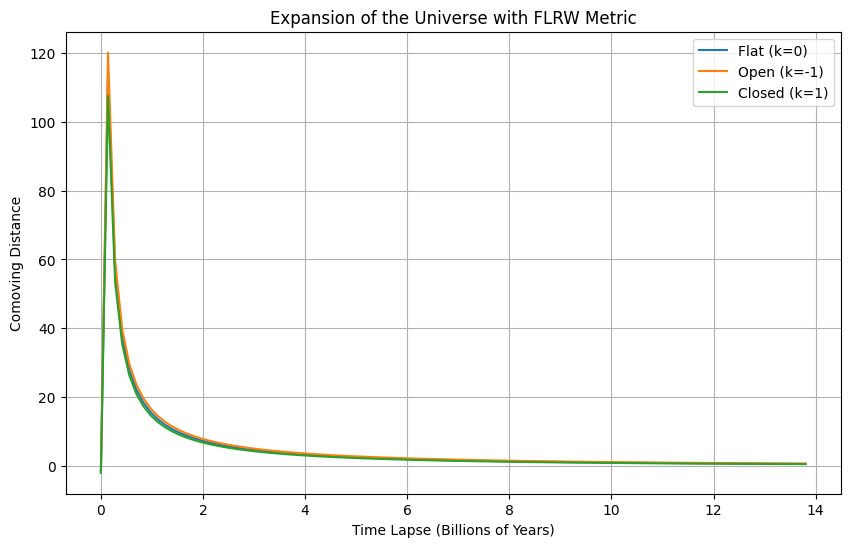

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Define the Friedmann-Lemaître-Robertson-Walker (FLRW) metric
def flrw_metric(a, Omega_m, Omega_k, Omega_lambda):
  """
  Calculates the Hubble parameter in the FLRW metric.

  Args:
    a: Scale factor.
    Omega_m: Matter density parameter.
    Omega_k: Curvature density parameter.
    Omega_lambda: Dark energy density parameter.

  Returns:
    The Hubble parameter.
  """
  return np.sqrt(Omega_m / a**3 + Omega_k / a**2 + Omega_lambda)

# Define the comoving distance
def comoving_distance(a, Omega_m, Omega_k, Omega_lambda):
  """
  Calculates the comoving distance.

  Args:
    a: Scale factor.
    Omega_m: Matter density parameter.
    Omega_k: Curvature density parameter.
    Omega_lambda: Dark energy density parameter.

  Returns:
    The comoving distance.
  """
  def integrand(a):
    return 1 / flrw_metric(a, Omega_m, Omega_k, Omega_lambda)
  return quad(integrand, 0, a)[0]

# Define the scale factors
a_values = np.linspace(0.01, 1, 100)

# Define the cosmological parameters
Omega_m = 0.3
Omega_lambda = 0.7

# Calculate the comoving distances for different curvatures
comoving_distances_flat = [comoving_distance(a, Omega_m, 0, Omega_lambda) for a in a_values]
comoving_distances_open = [comoving_distance(a, Omega_m, -0.1, Omega_lambda) for a in a_values]
comoving_distances_closed = [comoving_distance(a, Omega_m, 0.1, Omega_lambda) for a in a_values]

# Define the age of the universe in billions of years
age_universe = 13.8

# Define the time values in billions of years
t_values = np.linspace(0, age_universe, 100)

# Define a function to convert time to scale factor
def time_to_scale_factor(t, Omega_m, Omega_k, Omega_lambda):
    """
    Converts time to scale factor using numerical integration.

    Args:
        t: Time in billions of years.
        Omega_m: Matter density parameter.
        Omega_k: Curvature density parameter.
        Omega_lambda: Dark energy density parameter.

    Returns:
        The scale factor.
    """
    def integrand(a):
        return 1 / (a * flrw_metric(a, Omega_m, Omega_k, Omega_lambda))
    return quad(integrand, 0, 1)[0] / (t / age_universe)

# Calculate the scale factors for each curvature
a_values_flat = [time_to_scale_factor(t, Omega_m, 0, Omega_lambda) for t in t_values]
a_values_open = [time_to_scale_factor(t, Omega_m, -0.1, Omega_lambda) for t in t_values]
a_values_closed = [time_to_scale_factor(t, Omega_m, 0.1, Omega_lambda) for t in t_values]

# Calculate the comoving distances for different curvatures
comoving_distances_flat = [comoving_distance(a, Omega_m, 0, Omega_lambda) for a in a_values_flat]
comoving_distances_open = [comoving_distance(a, Omega_m, -0.1, Omega_lambda) for a in a_values_open]
comoving_distances_closed = [comoving_distance(a, Omega_m, 0.1, Omega_lambda) for a in a_values_closed]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t_values, comoving_distances_flat, label="Flat (k=0)")
plt.plot(t_values, comoving_distances_open, label="Open (k=-1)")
plt.plot(t_values, comoving_distances_closed, label="Closed (k=1)")
plt.xlabel("Time Lapse (Billions of Years)")
plt.ylabel("Comoving Distance")
plt.title("Expansion of the Universe with FLRW Metric")
plt.legend()
plt.grid(True)
plt.show()

**Visualization how scale factor changes with time for different curvature scenarios**

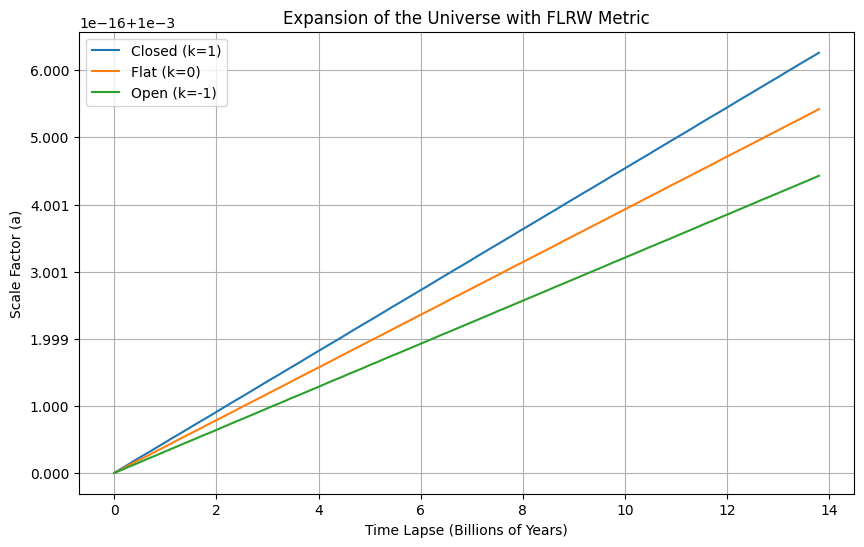

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the Friedmann equation
def friedmann_equation(a, t, Omega_m, Omega_k, Omega_lambda):
    """
    Calculates the derivative of the scale factor with respect to time.

    Args:
        a: Scale factor.
        t: Time in billions of years.
        Omega_m: Matter density parameter.
        Omega_k: Curvature density parameter.
        Omega_lambda: Dark energy density parameter.

    Returns:
        The derivative of the scale factor.
    """
    H0 = 70  # Hubble constant in km/s/Mpc
    H0_s = H0 / 3.086e+19  # Convert Hubble constant to 1/s
    return H0_s * a * np.sqrt(Omega_m / a**3 + Omega_k / a**2 + Omega_lambda)

# Define the time values in billions of years
t_values = np.linspace(0, 13.8, 100)  # Age of the universe

# Define the initial condition (scale factor at t=0)
a0 = 1e-3  # Very small initial value

# Define the cosmological parameters
Omega_m = 0.3
Omega_lambda = 0.7

# Solve the Friedmann equation for different curvatures
a_values_flat = odeint(friedmann_equation, a0, t_values, args=(Omega_m, 0, Omega_lambda))[:, 0]
a_values_open = odeint(friedmann_equation, a0, t_values, args=(Omega_m, -100, Omega_lambda))[:, 0]
a_values_closed = odeint(friedmann_equation, a0, t_values, args=(Omega_m, 100, Omega_lambda))[:, 0]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t_values, a_values_closed, label="Closed (k=1)")
plt.plot(t_values, a_values_flat, label="Flat (k=0)")
plt.plot(t_values, a_values_open, label="Open (k=-1)")
plt.xlabel("Time Lapse (Billions of Years)")
plt.ylabel("Scale Factor (a)")
plt.title("Expansion of the Universe with FLRW Metric")
plt.legend()
plt.grid(True)
plt.show()